# 2D Heliosphere Model


# Setup


## Imports


In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import os
import sys
from pathlib import Path

os.environ.setdefault("MPLCONFIGDIR", "/tmp/helio_n_matplotlib")

cwd = Path.cwd().resolve()
project_root = None
for candidate in (cwd, *cwd.parents, Path("/home/smdc/helio-n")):
    if (candidate / "Library").exists() and (candidate / "Config").exists():
        project_root = candidate
        break
assert (
    project_root is not None
), "Could not locate the helio-n project root for notebook imports."
if str(project_root) not in sys.path:
    sys.path.append(str(project_root))

import numpy as np
import pandas as pd
from ipywidgets import interact, widgets

from Library.SW.Ballistic import (
    init_accumulators,
    postprocess_max_field,
    prepare_seed_inputs,
    run_bulk_propagation,
)
from Library.SW.Config import (
    load_ballistic_spec,
    load_sw_runtime_spec,
)
from Library.SW.Coords import (
    build_grid_axes,
    build_transport_state,
    compute_rotation_state,
)
from Library.SW.Inputs import (
    DEFAULT_SQL_CONNECTION,
    DEFAULT_SQL_QUERY,
    build_ace_earth_swx_frame,
    build_model_input_series,
    load_ace_earth_frame,
    load_sw_input_frame,
)
from Library.SW.Visualization import (
    build_satellite_comparison_frame,
    export_polar_animation,
    plot_polar_snapshot,
)
from Models.CH_SW_Correspondence.Shugay import load as load_shugay
from Models.CH_SW_Correspondence.Shugay_Slow_SW import load as load_shugay_slow_sw


## Global Parameters


In [3]:
empirical = load_shugay()
slow_sw_empirical = load_shugay_slow_sw()
ballistic = load_ballistic_spec()
runtime = load_sw_runtime_spec()
slow_sw_patch = True

# Keep short aliases for the repeated physics terms used throughout the notebook.
# superresolution_enabled = bool(ballistic["superresolution_enabled"])
superresolution_enabled = False

time_step_minutes = (
    int(ballistic["superresolution_step_minutes"])
    if superresolution_enabled
    else int(ballistic["base_time_step_minutes"])
)
time_step_hours = float(time_step_minutes) / 60.0
time_freq = f"{int(time_step_minutes)}min"
phi_step_minutes = ballistic["phi_step_minutes"]

cr_days = ballistic["cr_days"]
r0 = ballistic["r0"]
rSolar = ballistic["r_solar_km"]
R_max = ballistic["r_max"]
horizon_hours = ballistic["horizon_hours"]
memory_guard_enabled = ballistic["memory_guard_enabled"]
simulation_pad_days = ballistic["simulation_pad_days"]

dense_memory_budget_gb = runtime["dense_memory_budget_gb"]
max_seed_batch = runtime["max_seed_batch"]
post_chunk_t = runtime["post_chunk_t"]

print(
    "Shugay.py:",
    empirical.source_path,
    "| Ballistic.json:",
    ballistic["json_path"],
)
print(
    "superresolution_enabled:",
    superresolution_enabled,
    "| dt(min):",
    time_step_minutes,
    "| freq:",
    time_freq,
)
print("phi_step_minutes:", phi_step_minutes)
print(
    "dense_memory_budget_gb:",
    dense_memory_budget_gb,
    "| max_seed_batch:",
    max_seed_batch,
)


Shugay.py: /Users/aosh/Developer/helio-n/Models/CH_SW_Correspondence/Shugay.py | Ballistic.json: /Users/aosh/Developer/helio-n/Config/SW/Ballistic.json
superresolution_enabled: False | dt(min): 60 | freq: 60min
phi_step_minutes: 120
dense_memory_budget_gb: 10.0 | max_seed_batch: 256


## Data Loading And Input Speed Series


In [4]:
start_dt = pd.Timestamp("2016-12-15")
end_dt = pd.Timestamp("2017-02-15")

input_source = "parquet"
input_parquet_path = Path("Data/CH Area.parquet")
sql_query = DEFAULT_SQL_QUERY
sql_connection_kwargs = DEFAULT_SQL_CONNECTION.copy()

In [5]:
df_sdo_sw_test = load_sw_input_frame(
    start_dt=start_dt,
    end_dt=end_dt,
    source=input_source,
    input_parquet_path=input_parquet_path,
    query=sql_query,
    connection_kwargs=sql_connection_kwargs,
)
print(
    "Loaded propagation input from:",
    input_parquet_path if input_source == "parquet" else "SQL query",
)
print("Rows in filtered input:", len(df_sdo_sw_test))
df_sdo_sw_test.head()

Loaded propagation input from: Data/CH Area.parquet
Rows in filtered input: 1473


,dt,sw_speed_1,ch_area_1,sw_speed_2,ch_area_2,ch_relative_area,forecast_sw_speed
0,2016-12-15 15:00:00,NaN,NaN,NaN,NaN,NaN,NaN
1,2016-12-15 16:00:00,NaN,0.33,NaN,NaN,0.33,NaN
2,2016-12-15 17:00:00,NaN,0.31,NaN,NaN,0.31,NaN
3,2016-12-15 18:00:00,315.60137,0.30,NaN,NaN,0.30,315.60137
4,2016-12-15 19:00:00,315.09968,0.30,NaN,NaN,0.30,315.09968


## Empirical SW Speed Model


In [6]:
sample_time = pd.date_range("2017-01-01 00:00:00", periods=3, freq="1h")
sample_area = pd.Series([0.0, 0.33, 0.66], index=sample_time, name="ch_relative_area")
pd.DataFrame(
    {
        "ch_relative_area": sample_area,
        "v_empirical": empirical.v_from_area(sample_area, t=sample_time),
    }
)


,ch_relative_area,v_empirical
2017-01-01 00:00:00,0.00,300.000000
2017-01-01 01:00:00,0.33,392.550947
2017-01-01 02:00:00,0.66,440.281004


## Simulation Input Preparation


In [7]:
prepared_inputs = build_model_input_series(
    sdo_input_df=df_sdo_sw_test,
    empirical=empirical,
    superresolution_enabled=superresolution_enabled,
    time_freq=time_freq,
    simulation_pad_days=simulation_pad_days,
)

sdo_input_df = prepared_inputs["sdo_input_df"]
df_v = prepared_inputs["df_v"]
df_ch_area = prepared_inputs["df_ch_area"]
sim_start = prepared_inputs["sim_start"]
sim_end = prepared_inputs["sim_end"]

print("Rows in df_v:", len(df_v), "| cadence:", time_freq)
print("Rows in df_ch_area:", len(df_ch_area))
df_v.head()

Rows in df_v: 1472 | cadence: 60min
Rows in df_ch_area: 1472


,v
time,
2016-12-15 16:00:00,392.550947
2016-12-15 17:00:00,389.143467
2016-12-15 18:00:00,387.406807
2016-12-15 19:00:00,387.406807
2016-12-15 20:00:00,385.646832


# Model Definition


## Rotation And Geometry Constants


In [8]:
rotation = compute_rotation_state(
    cr_days=cr_days,
    phi_step_minutes=phi_step_minutes,
)
cr_time = rotation.cr_time
omega = rotation.omega
phi_step = rotation.phi_step

print("omega * 3600:", omega * 3600)
print("phi_step_used (deg):", phi_step, "| from phi_step_minutes:", phi_step_minutes)
print(
    "time_step_used (h):",
    time_step_hours,
    "| freq:",
    time_freq,
    "| superresolution:",
    superresolution_enabled,
)
print("r0:", r0, "| rSolar(km):", rSolar, "| R_max:", R_max)

omega * 3600: 0.5555555555555556
phi_step_used (deg): 1.1111111111111112 | from phi_step_minutes: 120
time_step_used (h): 1.0 | freq: 60min | superresolution: False
r0: 20 | rSolar(km): 700000.0 | R_max: 215


## Grid Construction (time, phi, R)


In [9]:
grid = build_grid_axes(
    sim_start=sim_start,
    sim_end=sim_end,
    time_freq=time_freq,
    phi_step=phi_step,
    r0=r0,
    r_max=R_max,
    dense_memory_budget_gb=dense_memory_budget_gb,
    memory_guard_enabled=memory_guard_enabled,
)

time_axis = grid.time_axis
phi_axis = grid.phi_axis
r_axis = grid.r_axis
n_cells = grid.n_cells
est_runtime_gb = grid.est_runtime_gb

print("Grid shape (t, phi, R):", (len(time_axis), len(phi_axis), len(r_axis)))
print(
    f"Estimated dense propagation memory: {est_runtime_gb:.2f} GB"
)

Grid shape (t, phi, R): (1640, 324, 196)
Estimated dense propagation memory: 0.67 GB


In [10]:
transport = build_transport_state(
    time_axis=time_axis,
    phi_axis=phi_axis,
    rotation_state=rotation,
    horizon_hours=horizon_hours,
    time_step_hours=time_step_hours,
    r_solar_km=rSolar,
)

t0_ref = transport.t0_ref
horizon_steps = transport.horizon_steps
h_step_idx = transport.h_step_idx
r_kernel_scale = transport.r_kernel_scale
cr_steps = transport.cr_steps
phi_delay_steps = transport.phi_delay_steps
phi_delay_offsets = transport.phi_delay_offsets
phi_delay_alpha = transport.phi_delay_alpha

print("Initialized dense propagation grid.")
print("time range:", time_axis.min(), "->", time_axis.max())
print("phi bins:", len(phi_axis), "R bins:", len(r_axis))

valid_seed_mask = (df_v.index >= time_axis.min()) & (df_v.index <= time_axis.max())
df_v_run = df_v.loc[valid_seed_mask].copy()
print("Seeds in simulation range:", len(df_v_run), "of", len(df_v))

Initialized dense propagation grid.
time range: 2016-12-15 16:00:00 -> 2017-02-21 23:00:00
phi bins: 324 R bins: 196
Seeds in simulation range: 1472 of 1472


## Propagation Functions


In [11]:
acc = init_accumulators(
    n_t=len(time_axis),
    n_p=len(phi_axis),
    n_r=len(r_axis),
)

V_accum_max = acc.V_accum_max
cr_flat = acc.cr_flat
dims = (len(time_axis), len(phi_axis), len(r_axis))

(
    seed_vals,
    v_prev,
    v_next,
    seed_t_idx,
    seed_cr_idx_arr,
    seed_r_idx,
) = prepare_seed_inputs(
    df_v_run=df_v_run,
    cr_steps=cr_steps,
    horizon_steps=horizon_steps,
    time_freq=time_freq,
    t0_ref=t0_ref,
    time_step_hours=time_step_hours,
    r_kernel_scale=r_kernel_scale,
    r0=r0,
)

# Experiments


## Bulk Propagation Across Time


In [12]:
stats = run_bulk_propagation(
    seed_vals=seed_vals,
    v_prev=v_prev,
    v_next=v_next,
    seed_t_idx=seed_t_idx,
    seed_cr_idx_arr=seed_cr_idx_arr,
    seed_r_idx=seed_r_idx,
    h_step_idx=h_step_idx,
    phi_delay_offsets=phi_delay_offsets,
    phi_delay_alpha=phi_delay_alpha,
    n_t=len(time_axis),
    n_p=len(phi_axis),
    n_r=len(r_axis),
    V_accum_max=V_accum_max,
    cr_flat=cr_flat,
    max_seed_batch=max_seed_batch,
)

filled = stats.filled
total = stats.total
prop_seconds = stats.prop_seconds

print(
    "time step (h):",
    time_step_hours,
    "| bins per hour:",
    int(round(1.0 / time_step_hours)),
)
print(
    "Accumulated non-empty cells:",
    filled,
    "/",
    total,
    f"({100.0 * filled / total:.2f}%)",
)
print(f"Propagation runtime: {prop_seconds:.2f} s ({prop_seconds / 60.0:.2f} min)")
print(f"Seeds processed: {stats.seeds_processed}")

2D propagate:   0%|          | 0/6 [00:00<?, ?batch/s]

time step (h): 1.0 | bins per hour: 1
Accumulated non-empty cells: 73304032 / 104146560 (70.39%)
Propagation runtime: 1.26 s (0.02 min)
Seeds processed: 1472


## Post-Processing


In [13]:
slow_sw_speed = empirical.slow_sw_speed(time_axis)
slow_sw_patch_speed = slow_sw_empirical.slow_sw_speed(time_axis)

post = postprocess_max_field(
    V_accum_max=V_accum_max,
    slow_sw_speed=slow_sw_speed,
    post_chunk_t=post_chunk_t,
)

V_grid = post.V_grid
slow_sw_pred_mask = post.max_slow_sw_pred_mask
post_vlims_raw = post.max_vlims_raw
post_fields = V_grid
post_vlims = post_vlims_raw

print("Predicted slow-SW cells (max mode):", int(slow_sw_pred_mask.sum()))
print("raw v min/max (max mode):", post_vlims_raw)

Post-processing:   0%|          | 0/13 [00:00<?, ?chunk/s]

Predicted slow-SW cells (max mode): 19842384
raw v min/max (max mode): (300.0, 704.135009765625)


# Analysis


## Visualization


## Satellite Data


In [14]:
stereo_parquet_path = Path(
    "/Users/aosh/Developer/Shock-and-Awe/Data/2022-11-24 19-10-00/STEREO.parquet"
)
earth_radii_per_solar_radius = 109.0763707060096

stereo_a_df = pd.read_parquet(
    stereo_parquet_path,
    columns=[
        "N_p",
        "V",
        "T_p",
        "radialDistance",
        "heliographicLatitude",
        "heliographicLongitude",
    ],
).copy()
stereo_a_df.index = pd.to_datetime(stereo_a_df.index, utc=True).tz_convert(None)
stereo_a_df = stereo_a_df.loc[time_axis.min() : time_axis.max()]
stereo_a_df = stereo_a_df.rename(
    columns={
        "N_p": "n_p",
        "V": "v",
        "T_p": "t_p",
        "radialDistance": "r_target",
        "heliographicLatitude": "lat_hge",
        "heliographicLongitude": "phi_target",
    }
)
for column in stereo_a_df.columns:
    stereo_a_df[column] = pd.to_numeric(stereo_a_df[column], errors="coerce")
stereo_a_df["r_target"] = stereo_a_df["r_target"] / earth_radii_per_solar_radius
stereo_a_df = stereo_a_df.resample(time_freq).mean().reindex(time_axis)
stereo_a_df.attrs["sat"] = "stereo_a"
stereo_a_df.attrs["label"] = "STEREO-A"
stereo_a_df.attrs["coord_frame"] = "HGE"
stereo_a_df


,n_p,v,t_p,r_target,lat_hge,phi_target
2016-12-15 16:00:00,3.369000,411.875556,47788.301887,206.434101,5.1,223.300003
2016-12-15 17:00:00,4.562478,419.523333,63571.034483,206.434101,5.1,223.349791
2016-12-15 18:00:00,4.536589,418.822222,46889.122807,206.434101,5.1,223.399994
2016-12-15 19:00:00,4.287133,419.205556,59538.518519,206.434101,5.1,223.399994
2016-12-15 20:00:00,4.433111,415.726667,53616.333333,206.434101,5.1,223.449789
...,...,...,...,...,...,...
2017-02-21 19:00:00,NaN,NaN,NaN,NaN,NaN,NaN
2017-02-21 20:00:00,NaN,NaN,NaN,NaN,NaN,NaN
2017-02-21 21:00:00,NaN,NaN,NaN,NaN,NaN,NaN
2017-02-21 22:00:00,NaN,NaN,NaN,NaN,NaN,NaN


## Interactive Exploration


In [15]:
plot_sats = [
    {
        "sat": "ace_earth",
        "label": "ACE @ Earth",
        "phi_target": ballistic["earth_phi_target"],
        "r_target": ballistic["earth_r_target"],
    },
    {
        "sat": "stereo_a",
        "label": "STEREO-A",
        "phi_target": 0.0,
        "r_target": ballistic["earth_r_target"],
    },
]

satellite_frames = {
    "ace_earth": load_ace_earth_frame(),
    "stereo_a": stereo_a_df,
}
satellite_swx_frames = {"ace_earth": build_ace_earth_swx_frame(sdo_input_df)}
comparison_frames = {}
for sat_spec in plot_sats:
    sat_name = sat_spec["sat"]
    df_sat = satellite_frames[sat_name].copy()
    df_sat.attrs["label"] = sat_spec["label"]
    comparison_frames[sat_name] = build_satellite_comparison_frame(
        time_axis=time_axis,
        phi_axis=phi_axis,
        r_axis=r_axis,
        grid_raw=V_grid,
        slow_sw_pred_mask=slow_sw_pred_mask,
        df_sat=df_sat,
        df_swx=satellite_swx_frames.get(sat_name),
        phi_target=sat_spec["phi_target"],
        r_target=sat_spec["r_target"],
        slow_sw_speed=slow_sw_patch_speed,
        slow_sw_patch=slow_sw_patch,
        cr_days=cr_days,
        draw_slow_sw=True,
    )

for sat_spec in plot_sats:
    sat_name = sat_spec["sat"]
    df_sat = satellite_frames[sat_name]
    print(
        sat_spec["label"],
        "rows:",
        len(df_sat),
        "range:",
        df_sat.index.min(),
        "->",
        df_sat.index.max(),
    )


ACE @ Earth rows: 123074 range: 2010-08-01 00:00:00 -> 2026-01-01 00:00:00
STEREO-A rows: 1640 range: 2016-12-15 16:00:00 -> 2017-02-21 23:00:00


In [16]:
satellite_frames["ace_earth"]['2016-12-15 16:00:00':]

,v
date,
2016-12-15 16:00:00,387.670000
2016-12-15 17:00:00,389.880000
2016-12-15 18:00:00,385.492982
2016-12-15 19:00:00,383.477778
2016-12-15 20:00:00,385.736667
...,...
2025-12-31 20:00:00,465.722500
2025-12-31 21:00:00,454.912500
2025-12-31 22:00:00,466.157273


In [ ]:
date_strs = [d.strftime("%Y-%m-%d %H:%M:%S") for d in time_axis]
print(
    f"Earth mapping check: R=215 -> r_idx={np.argmin(np.abs(r_axis - ballistic['earth_r_target']))}"
)


def plot_polar(date_str):
    plot_polar_snapshot(
        date_str=date_str,
        time_axis=time_axis,
        phi_axis=phi_axis,
        r_axis=r_axis,
        grid_raw=V_grid,
        post_vlims_raw=post_vlims_raw,
        slow_sw_pred_mask=slow_sw_pred_mask,
        slow_sw_speed=slow_sw_speed,
        comparison_frames=comparison_frames,
        draw_slow_sw=True,
        cr_days=cr_days,
    )


interact(
    plot_polar,
    date_str=widgets.SelectionSlider(
        options=date_strs,
        value=date_strs[0],
        description="date",
        continuous_update=False,
        layout=widgets.Layout(width="90%"),
    ),
)


Earth mapping check: R=215 -> r_idx=195


interactive(children=(SelectionSlider(continuous_update=False, description='date', layout=Layout(width='90%'),…

<function __main__.plot_polar(date_str)>

### Forecast Skill Stats


In [18]:
def first_present_series(frame, candidates):
    for column in candidates:
        if column in frame.columns:
            return pd.to_numeric(frame[column], errors="coerce")
    return None


def build_hourly_eval_index(start_dt, end_dt):
    return pd.date_range(pd.Timestamp(start_dt), pd.Timestamp(end_dt), freq="1h")


def prepare_hourly_series(series, start_dt, end_dt, output_name):
    prepared = pd.Series(
        pd.to_numeric(series, errors="coerce").to_numpy(),
        index=pd.DatetimeIndex(series.index),
        name=output_name,
    )
    prepared = prepared[~prepared.index.duplicated(keep="last")].sort_index()
    prepared = prepared.loc[pd.Timestamp(start_dt) : pd.Timestamp(end_dt)]
    prepared = prepared.resample("1h").mean()
    return prepared.reindex(build_hourly_eval_index(start_dt, end_dt))


def shift_and_prepare_hourly_series(
    series,
    shift_timedelta,
    start_dt,
    end_dt,
    output_name,
):
    shifted = pd.Series(
        pd.to_numeric(series, errors="coerce").to_numpy(),
        index=pd.DatetimeIndex(series.index) + shift_timedelta,
        name=output_name,
    )
    return prepare_hourly_series(shifted, start_dt, end_dt, output_name)


def compute_forecast_stats(actual, forecast):
    paired = pd.concat(
        [
            pd.to_numeric(actual, errors="coerce").rename("actual"),
            pd.to_numeric(forecast, errors="coerce").rename("forecast"),
        ],
        axis=1,
    ).dropna()
    if len(paired) == 0:
        return {
            "n_samples": 0,
            "pearson_r": np.nan,
            "rmse": np.nan,
            "mae": np.nan,
            "bias": np.nan,
            "mape_pct": np.nan,
        }

    err = paired["forecast"] - paired["actual"]
    abs_pct_err = np.abs(err / paired["actual"].replace(0.0, np.nan)) * 100.0
    pearson_r = np.nan
    if len(paired) >= 2:
        pearson_r = float(paired["actual"].corr(paired["forecast"]))

    return {
        "n_samples": int(len(paired)),
        "pearson_r": pearson_r,
        "rmse": float(np.sqrt(np.mean(err**2))),
        "mae": float(np.mean(np.abs(err))),
        "bias": float(np.mean(err)),
        "mape_pct": float(np.nanmean(abs_pct_err)),
    }


def build_1cr_ago_series(frame, cr_days, start_dt, end_dt):
    if "v_1cr_ago" in frame.columns:
        return prepare_hourly_series(frame["v_1cr_ago"], start_dt, end_dt, "v_1cr_ago")

    actual = first_present_series(frame, ["v_real", "v_ace"])
    assert actual is not None, "No factual speed column found for 1CR-ago fallback"

    return shift_and_prepare_hourly_series(
        actual,
        pd.Timedelta(days=float(cr_days)),
        start_dt,
        end_dt,
        "v_1cr_ago",
    )


def build_shifted_model_series(frame, cr_days, start_dt, end_dt):
    model = first_present_series(frame, ["v_predict", "v_model_earth"])
    assert model is not None, "No model forecast column found for 1CR model shift"

    return shift_and_prepare_hourly_series(
        model,
        pd.Timedelta(days=float(cr_days)),
        start_dt,
        end_dt,
        "v_model_1cr_shifted",
    )


rows = []
swx_diagnostic_rows = []
for sat_name, frame in comparison_frames.items():
    sat_label = frame.attrs.get("label", sat_name)
    actual_source = first_present_series(frame, ["v_real", "v_ace"])
    assert actual_source is not None, f"No factual speed column found for {sat_label}"
    actual = prepare_hourly_series(actual_source, start_dt, end_dt, "actual")

    forecast_specs = []
    if sat_name == "ace_earth":
        swx_source = first_present_series(frame, ["v_swx", "forecast_sw_speed"])
        if swx_source is not None:
            swx = prepare_hourly_series(swx_source, start_dt, end_dt, "v_swx")
            forecast_specs.append(("SWX forecast", swx))

            raw_swx_stats = compute_forecast_stats(actual, swx)
            best_short_shift = None
            for shift_hours in range(-48, 49, 6):
                shifted_swx = shift_and_prepare_hourly_series(
                    swx_source,
                    pd.Timedelta(hours=float(shift_hours)),
                    start_dt,
                    end_dt,
                    "v_swx_shifted",
                )
                stats = compute_forecast_stats(actual, shifted_swx)
                if pd.notna(stats["pearson_r"]) and (
                    best_short_shift is None
                    or stats["pearson_r"] > best_short_shift["pearson_r"]
                ):
                    best_short_shift = {"shift_hours": shift_hours, **stats}

            min_wide_samples = max(200, int(np.ceil(0.4 * raw_swx_stats["n_samples"])))
            best_wide_shift = None
            for shift_hours in range(-24 * 40, 24 * 40 + 1, 6):
                shifted_swx = shift_and_prepare_hourly_series(
                    swx_source,
                    pd.Timedelta(hours=float(shift_hours)),
                    start_dt,
                    end_dt,
                    "v_swx_shifted",
                )
                stats = compute_forecast_stats(actual, shifted_swx)
                if stats["n_samples"] >= min_wide_samples and pd.notna(stats["pearson_r"]) and (
                    best_wide_shift is None
                    or stats["pearson_r"] > best_wide_shift["pearson_r"]
                ):
                    best_wide_shift = {"shift_hours": shift_hours, **stats}

            swx_diagnostic_rows.extend(
                [
                    {
                        "alignment": "raw 0h",
                        "shift_hours": 0,
                        "n_samples": raw_swx_stats["n_samples"],
                        "pearson_r": raw_swx_stats["pearson_r"],
                    },
                    {
                        "alignment": "best within +/-48h",
                        "shift_hours": best_short_shift["shift_hours"] if best_short_shift is not None else np.nan,
                        "n_samples": best_short_shift["n_samples"] if best_short_shift is not None else 0,
                        "pearson_r": best_short_shift["pearson_r"] if best_short_shift is not None else np.nan,
                    },
                    {
                        "alignment": f"best within +/-40d (>= {min_wide_samples} samples)",
                        "shift_hours": best_wide_shift["shift_hours"] if best_wide_shift is not None else np.nan,
                        "n_samples": best_wide_shift["n_samples"] if best_wide_shift is not None else 0,
                        "pearson_r": best_wide_shift["pearson_r"] if best_wide_shift is not None else np.nan,
                    },
                ]
            )

    forecast_specs.append(
        (
            "v_prev_cr",
            build_1cr_ago_series(frame, cr_days=cr_days, start_dt=start_dt, end_dt=end_dt),
        )
    )

    model_source = first_present_series(frame, ["v_predict", "v_model_earth"])
    if model_source is not None:
        model = prepare_hourly_series(model_source, start_dt, end_dt, "v_model")
        forecast_specs.append(("My forecast", model))
        if sat_name.startswith("stereo"):
            forecast_specs.append(
                (
                    "My forecast, 1CR shifted",
                    build_shifted_model_series(
                        frame,
                        cr_days=cr_days,
                        start_dt=start_dt,
                        end_dt=end_dt,
                    ),
                )
            )

    for forecast_name, forecast in forecast_specs:
        rows.append(
            {
                "sat": sat_label,
                "forecast": forecast_name,
                **compute_forecast_stats(actual, forecast),
            }
        )

stats_df = pd.DataFrame(rows)
forecast_order = {
    "SWX forecast": 0,
    "v_prev_cr": 1,
    "My forecast": 2,
    "My forecast, 1CR shifted": 3,
}
stats_df["forecast_order"] = stats_df["forecast"].map(forecast_order)
stats_df = stats_df.sort_values(["sat", "forecast_order"]).drop(columns=["forecast_order"])
stats_df = stats_df.set_index(["sat", "forecast"])
stats_df = stats_df.round(
    {
        "pearson_r": 3,
        "rmse": 1,
        "mae": 1,
        "bias": 1,
        "mape_pct": 2,
    }
)

if swx_diagnostic_rows:
    swx_diagnostic_df = pd.DataFrame(swx_diagnostic_rows).round({"pearson_r": 3})
    print("ACE SWX timing diagnostic:")
    print(swx_diagnostic_df.to_string(index=False))
    print()

stats_df


ACE SWX timing diagnostic:
                          alignment  shift_hours  n_samples  pearson_r
                             raw 0h            0       1471      0.642
                 best within +/-48h           12       1459      0.665
best within +/-40d (>= 589 samples)           12       1459      0.665



n_samples  pearson_r   rmse    mae  \
sat         forecast                                                       
ACE @ Earth SWX forecast                   1471      0.642   97.4   74.0   
            v_prev_cr                      1482      0.605  113.2   86.1   
            My forecast                    1122      0.756   96.4   71.5   
STEREO-A    v_prev_cr                       825      0.561   99.3   76.0   
            My forecast                     792     -0.009  149.1  127.6   
            My forecast, 1CR shifted        246      0.042  134.4  124.1   

                                      bias  mape_pct  
sat         forecast                                  
ACE @ Earth SWX forecast             -19.8     15.56  
            v_prev_cr                -14.4     17.80  
            My forecast              -46.7     14.05  
STEREO-A    v_prev_cr                 -7.4     17.29  
            My forecast                0.8     28.94  
            My forecast, 1CR shifted  47.1     32.08

### Animation Export


Export MP4:   0%|          | 0/820 [00:00<?, ?frame/s]

CalledProcessError: Command '['ffmpeg', '-f', 'rawvideo', '-vcodec', 'rawvideo', '-s', '1420x680', '-pix_fmt', 'rgba', '-framerate', '30', '-loglevel', 'error', '-i', 'pipe:', '-vcodec', 'libx264', '-preset', 'ultrafast', '-crf', '23', '-pix_fmt', 'yuv420p', '-threads', '0', '-y', 'Outputs/SW/SW Polar Animation.mp4']' returned non-zero exit status 255.

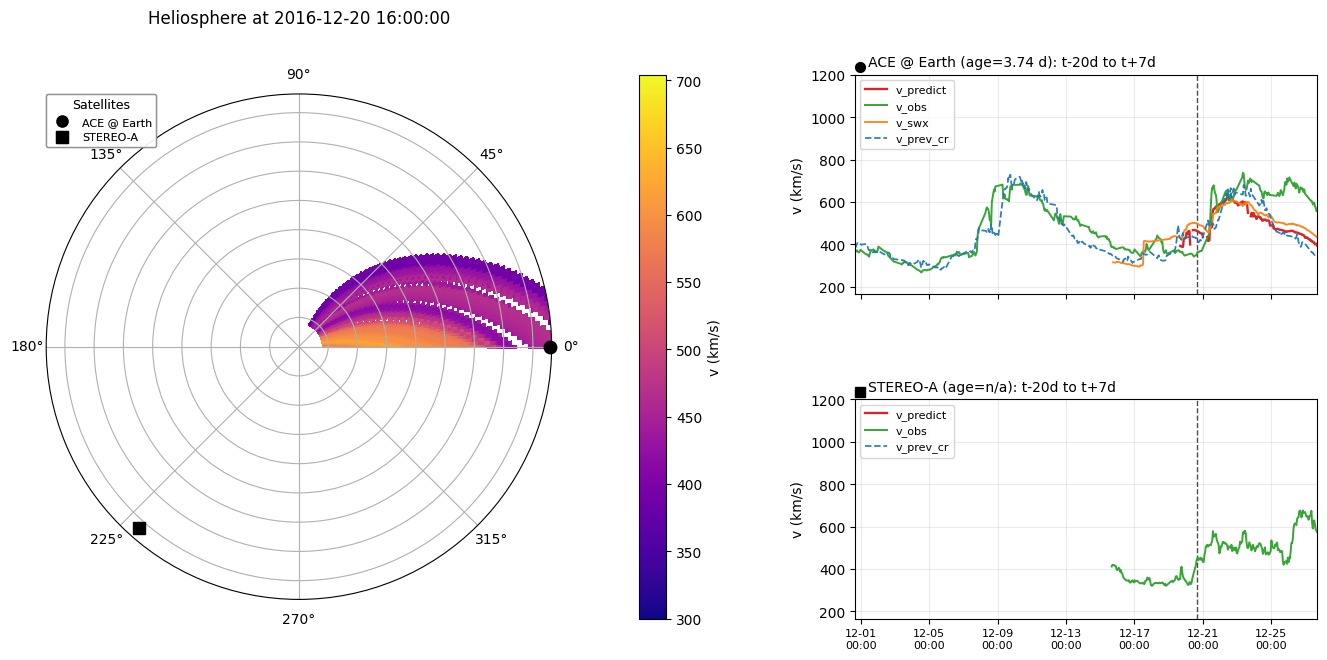

In [19]:
anim_fps = 30
anim_1h_mult = 2.0
anim_dpi = runtime["animation_dpi"]
anim_outfile = Path("Outputs/SW/SW Polar Animation.mp4")

primary_sat = plot_sats[0]["sat"]
primary_frame_anim = comparison_frames[primary_sat]
animation_stats = export_polar_animation(
    anim_outfile=anim_outfile,
    time_axis=time_axis,
    phi_axis=phi_axis,
    r_axis=r_axis,
    grid_raw=V_grid,
    post_vlims_raw=post_vlims_raw,
    slow_sw_pred_mask=slow_sw_pred_mask,
    comparison_frames=comparison_frames,
    time_step_minutes=time_step_minutes,
    slow_sw_speed=slow_sw_speed,
    cr_days=cr_days,
    draw_slow_sw=True,
    anim_fps=anim_fps,
    anim_1h_mult=anim_1h_mult,
    anim_dpi=anim_dpi,
)
print(animation_stats)


# Outputs


In [ ]:
# out_dir = Path("Outputs/SW")
# out_dir.mkdir(parents=True, exist_ok=True)
# out_parquet = out_dir / "SW Earth Series.parquet"

# comparison_frames[primary_sat].loc[time_axis.min() : time_axis.max()].to_parquet(out_parquet)
# print("Saved", out_parquet)


In [ ]:
# earth_phi_target = float(ballistic["earth_phi_target"])
# earth_r_target = float(ballistic["earth_r_target"])
# phi0_idx = int(np.argmin(np.abs(phi_axis - earth_phi_target)))
# r215_idx = int(np.argmin(np.abs(r_axis - earth_r_target)))

# propagated_earth = pd.Series(
#     V_grid[:, phi0_idx, r215_idx],
#     index=time_axis,
#     name=f"v_propagated_r{int(earth_r_target)}_phi{int(earth_phi_target)}",
# )


# def classify_gap_transition(left_speed, right_speed):
#     if not np.isfinite(left_speed) or not np.isfinite(right_speed):
#         return "edge-missing"
#     if right_speed > left_speed:
#         return "lower -> higher"
#     if right_speed < left_speed:
#         return "higher -> lower"
#     return "equal -> equal"


# gap_mask = propagated_earth.isna()
# gap_groups = gap_mask.ne(gap_mask.shift().fillna(False)).cumsum()
# gap_rows = []

# for _, gap in propagated_earth[gap_mask].groupby(gap_groups[gap_mask]):
#     gap_start = gap.index[0]
#     gap_end = gap.index[-1]
#     start_i = propagated_earth.index.get_loc(gap_start)
#     end_i = propagated_earth.index.get_loc(gap_end)

#     left_i = start_i - 1 if start_i > 0 else None
#     right_i = end_i + 1 if end_i + 1 < len(propagated_earth) else None

#     left_time = propagated_earth.index[left_i] if left_i is not None else pd.NaT
#     right_time = propagated_earth.index[right_i] if right_i is not None else pd.NaT
#     left_speed = propagated_earth.iloc[left_i] if left_i is not None else np.nan
#     right_speed = propagated_earth.iloc[right_i] if right_i is not None else np.nan
#     transition = classify_gap_transition(left_speed, right_speed)

#     gap_rows.append(
#         {
#             "gap_start": gap_start,
#             "gap_end": gap_end,
#             "gap_steps": int(len(gap)),
#             "gap_hours": float(len(gap) * time_step_hours),
#             "left_time": left_time,
#             "left_speed": left_speed,
#             "right_time": right_time,
#             "right_speed": right_speed,
#             "speed_delta": right_speed - left_speed,
#             "transition": transition,
#         }
#     )

# gap_details = pd.DataFrame(gap_rows)

# if gap_details.empty:
#     print("No propagated gaps found at (R=215, phi=0).")
# else:
#     gap_summary = (
#         gap_details.groupby("transition", dropna=False)
#         .agg(
#             gap_count=("transition", "size"),
#             total_gap_hours=("gap_hours", "sum"),
#             median_gap_hours=("gap_hours", "median"),
#         )
#         .sort_values(["gap_count", "total_gap_hours"], ascending=False)
#     )

#     print(
#         f"Propagated gaps at (R={int(earth_r_target)}, phi={int(earth_phi_target)}):",
#         len(gap_details),
#     )
#     print(gap_summary)
#     gap_details = gap_details.sort_values("gap_start").reset_index(drop=True)
#     gap_details